# Extração de atributos usando redes neurais

Utilizaremos o modelo DINOv3 para extrair atributos de imagens e medir a similaridade entre elas. Isso possibilitará implementar uma função que busca imagens por similaridade.

## Carregamento do conjunto de dados

O dataset Oxford Pets possui 7300 imagens de 37 raças de cachorros e gatos. Utilizaremos ele para o exemplo

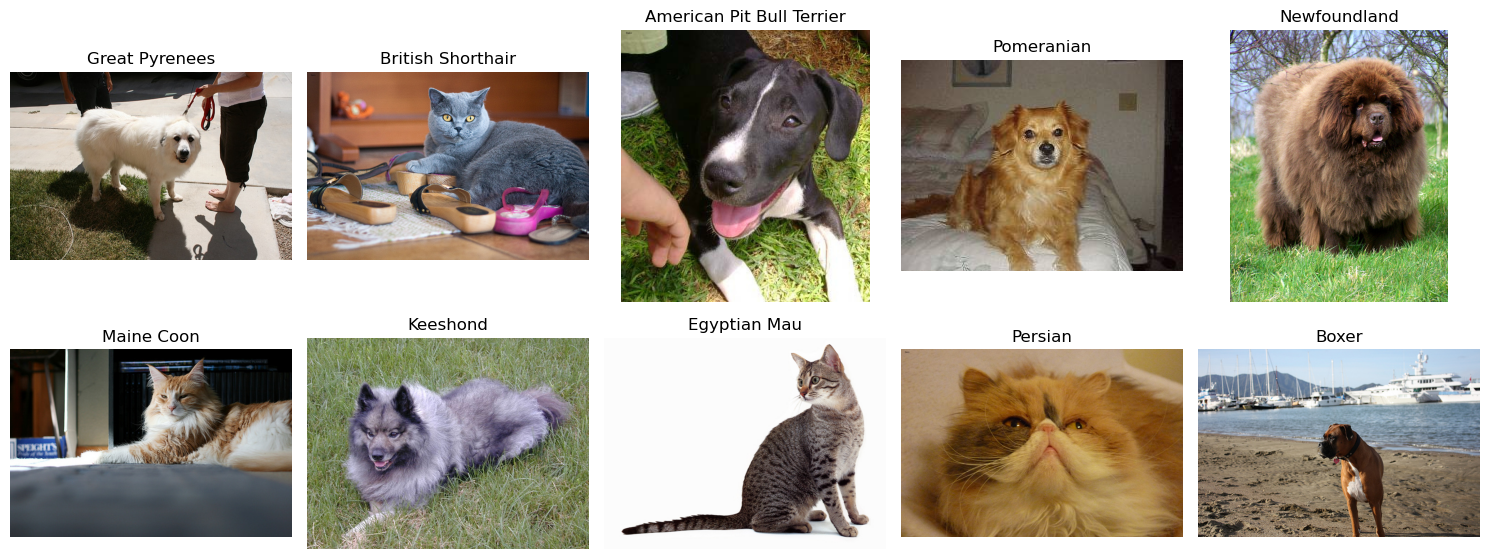

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.datasets import OxfordIIITPet
import timm

# Diretório onde o dataset será baixado. Ele ocupa cerca de 800MB.
dataset = OxfordIIITPet("~/datasets/classification", download=True)
classes = dataset.classes

# Sorteia 10 imagens aleatórias do dataset para visualização
random.seed(42)  
indices = random.sample(range(len(dataset)), 10)

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()
for idx, ax in zip(indices, axs):
    img, label = dataset[idx]
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Carregamento do modelo

In [3]:
# pretrained=True carrega o modelo treinado em um conjunto de mais de 1 bilhão de imagens
# num_classes=0 carrega o modelo como um extrator de atributos
model = timm.create_model(
    'convnext_tiny.dinov3_lvd1689m', 
    pretrained=True, 
    num_classes=0
)
# torch.compile é uma funcionalidade do PyTorch 2.0 que otimiza o modelo para melhorar a velocidade 
# de inferência, reduzindo a sobrecarga de execução.
model = torch.compile(model, mode="reduce-overhead")

# colocar o modelo em modo de avaliação é importante para garantir que ele se comporte corretamente 
# durante a inferência, desativando algumas funcionalidades utilizadas apenas para treinamento do 
# modelo.
model.eval()

# Exemplo de imagem de entrada para teste. Modelos do Pytorch sempre recebem um conjunto de images
# para processamento. Quando temos apenas uma imagem, precisamos adicionar uma dimensão extra para 
# representar um "conjunto de uma imagem".
dummy_image = torch.randn(1, 3, 224, 224)

with torch.inference_mode():
    features = model(dummy_image)

print(f"Tamanho dos atributos: {features.shape}")

Tamanho dos atributos: torch.Size([1, 768])


Outros modelos que podem ser utilizados, possuindo maior performance mas também maior custo computacional:

- convnext_small.dinov3_lvd1689m
- convnext_base.dinov3_lvd1689m
- convnext_large.dinov3_lvd1689m

- vit_small_patch16_dinov3.lvd1689m
- vit_small_plus_patch16_dinov3.lvd1689m
- vit_base_patch16_dinov3.lvd1689m
- vit_large_patch16_dinov3.lvd1689m
- vit_huge_plus_patch16_dinov3.lvd1689m


## Aplicação do modelo

### Pré-processamento da imagem

O modelo DINO funciona melhor se todas as imagens tiverem dimensões parecidas e forem normalizadas. Adicionalmente, as dimensões da imagem precisam ser múltiplos de 32, ou de 16 para algumas versões do modelo. Portanto, faremos funções para realizar essas tarefas.

In [4]:
import torchvision.transforms.v2.functional as transf

def get_optimal_width(h, w, target_height=256, patch_size=32):
    """Calcula a largura ideal para redimensionar a imagem mantendo a proporção e garantindo que 
    seja múltipla de patch_size."""

    aspect_ratio = w / h
    new_w = int(target_height * aspect_ratio)
    
    # Arredonda a largura para o múltiplo mais próximo de patch_size
    new_w = round(new_w / patch_size) * patch_size
    
    return new_w

def transform(img):
    """Transforma a imagem de entrada para o formato esperado pelo modelo"""
    
    w, h = img.size
    # Conversão de um objeto do PIL para um tensor do PyTorch
    img = transf.to_image(img)
    new_w = get_optimal_width(h, w)
    
    # Redimensiona a imagem para a altura de 256 pixels e a largura calculada
    img = transf.resize(img, (256, new_w), antialias=True)
    # Converte para float32 e divide por 255 para normalizar os valores dos pixels entre 0 e 1
    img = transf.to_dtype(img, torch.float32, scale=True)
    # Para cada imagem, os valores (0.485, 0.456, 0.406) são subtraídos dos canais R, G e B 
    # respectivamente, e os resultados são divididos pelos valores (0.229, 0.224, 0.225) para 
    # normalizar a imagem utilizando os mesmos parâmetros usados durante o treinamento do modelo. 
    # Isso ajuda a garantir que a imagem de entrada esteja no mesmo formato que as imagens usadas 
    # para treinar o modelo, melhorando a performance do modelo durante a inferência.
    img = transf.normalize(
        img,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )

    return img

img, label = dataset[0]
transformed_img = transform(img)
print(f"Tamanho da imagem original: {np.array(img).shape}")
print(f"Tamanho da imagem transformada: {transformed_img.shape}")

Tamanho da imagem original: (500, 394, 3)
Tamanho da imagem transformada: torch.Size([3, 256, 192])


In [5]:
def apply_model(model, img):
    """Aplica o modelo à imagem transformada e retorna os atributos extraídos."""

    img = transform(img)
    # Adiciona dimensão extra [1, 3, H, W] para representar um "conjunto de uma imagem"
    img = img.unsqueeze(0)
    
    with torch.inference_mode():
        features = model(img)

    # Normaliza os atributos de forma que cada vetor de atributos tenha norma 1, isto é,
    # np.sum(features**2) == 1. Isso é útil para garantir que os atributos estejam em uma escala 
    # consistente
    features = torch.nn.functional.normalize(features, p=2, dim=1)
        
    # Remove a dimensão extra e converte para numpy array
    features = features.squeeze(0).numpy()
    
    return features

In [ ]:
def build_embedding_matrix(model, dataset):
    """
    Constrói uma matriz de embeddings (N x D) onde N é o número de imagens no dataset e D é a
    dimensionalidade dos atributos extraídos pelo modelo.
    """
    
    model.eval()  
    embeddings = []
    
    for idx in range(len(dataset)):
        print(f"Processing image {idx+1}/{len(dataset)}", end="\r")

        img, label = dataset[idx]
        feature_vector = apply_model(model, img)
        embeddings.append(feature_vector)
            
    # Concatena a lista de embeddings em uma matriz NumPy de forma que cada linha corresponda 
    # aos atributos de uma imagem. O resultado é uma matriz de forma (N, D), onde N é o número 
    # de imagens e D é a dimensionalidade dos atributos.
    embedding_matrix = np.vstack(embeddings)
    
    return embedding_matrix

embedding_matrix = build_embedding_matrix(model, dataset)
# Salva a matriz de embeddings em um arquivo .npy para uso posterior. 
np.save("_embedding_matrix.npy", embedding_matrix)

## Busca de imagens por similaridade

In [6]:
embedding_matrix = np.load("_embedding_matrix.npy")
print(f"Tamanho da matriz final: {embedding_matrix.shape}")

Tamanho da matriz final: (3680, 768)


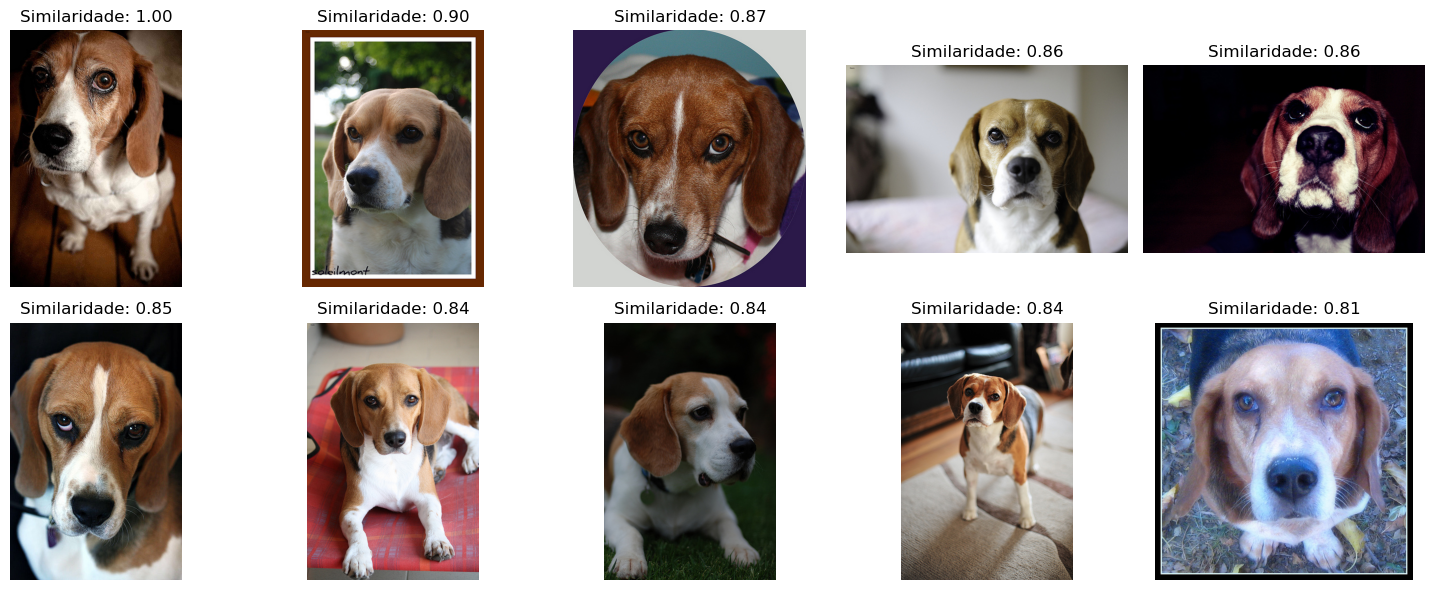

In [7]:
def find_similar_images(query_image, model, embedding_matrix, k=10):
    """Dado uma imagem de consulta, extrai seus atributos usando o modelo e calcula a similaridade
    com os atributos das imagens no dataset para retornar os índices e scores das k imagens mais
    similares."""

    model.eval()
    query_vector = apply_model(model, query_image)
    
    # Calcula a similaridade de coseno entre o vetor de consulta e cada vetor de atributos na 
    # matriz de embeddings.
    similarities = embedding_matrix @ query_vector
    
    # Encontra os índices dos k vetores de atributos mais similares ao vetor de consulta.
    top_k_indices = np.argsort(similarities)[::-1][:k]
    top_k_scores = similarities[top_k_indices]
    
    return top_k_indices, top_k_scores

# Imagem qualquer do dataset para teste. 
idx = 200
query_image, _ = dataset[idx]
top_k_indices, top_k_scores = find_similar_images(query_image, model, embedding_matrix)

# Visualiza as k imagens mais similares à imagem de consulta
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()
for idx, score, ax in zip(top_k_indices, top_k_scores, axs):
    img, label = dataset[idx]
    ax.imshow(img)
    ax.set_title(f"Similaridade: {score:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()